In [ ]:
import os
import sys
import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from scipy.spatial import cKDTree

sys.path.insert(0, '/home/users/zhiyi/PROJECTS_ANALYSIS')
from zhiyi.analysis.SE_analysis import get_site_index

BASE_DIR = Path('/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision')

SCRIP_NE30 = '/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne30x16/grids/UK_ne30x16_np4_SCRIP.nc'
SCRIP_NE60 = '/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne60/grids/UK_ne60_np4_SCRIP.nc'
FILEBASE_NE30 = ('/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.2_BB/atm/hist/'
                 'MUSICA_production3.2_BB.cam.h2.2018-MM-DD-03600.nc')
FILEBASE_NE60 = ('/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICAv0_ne60_production/atm/hist/'
                 'MUSICAv0_ne60_production.cam.h2.2018-MM-DD-03600.nc')

PLOT_START = pd.to_datetime('2018-05-22')
PLOT_END = pd.to_datetime('2018-06-14')
DATA_START = datetime.date(2018, 5, 22)
DATA_END = datetime.date(2018, 6, 15)

city_lonlat = {
    'London': [360 - 0.213492, 51.521050],
    'Manchester': [360 - 2.237881, 53.481520],
    'Glasgow': [360 - 4.259122, 55.858940],
    'Birmingham': [360 - 1.874978, 52.476145],
}

obs_files = {
    'London': ('/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/london_o3.csv', 0.5033),
    'Manchester': ('/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/manchester_o3.csv', 0.5007),
    'Glasgow': ('/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/glasgow_o3.csv', 0.4976),
    'Birmingham': ('/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/birmingham_o3.csv', 0.5005),
}

style = {
    'London': dict(color='tab:blue', marker='o'),
    'Manchester': dict(color='tab:green', marker='s'),
    'Glasgow': dict(color='tab:orange', marker='D'),
    'Birmingham': dict(color='tab:red', marker='^'),
}

In [ ]:
def collect_files(template, start, end):
    files = []
    cur = start
    while cur <= end:
        f = template.replace('MM', cur.strftime('%m')).replace('DD', cur.strftime('%d'))
        if os.path.exists(f):
            files.append(f)
        else:
            print(f'Warning: File not found - {f}, skipping.')
        cur += datetime.timedelta(days=1)
    return files


def read_obs_o3(path, factor):
    obs = pd.read_csv(path)
    obs['Date'] = pd.to_datetime(obs['Date'].astype(str) + ' ' + obs['Time'].astype(str), errors='coerce')
    obs = obs[(obs['Date'] >= PLOT_START) & (obs['Date'] <= PLOT_END)].sort_values('Date')
    obs = obs[['Date', 'average']].dropna().copy()
    obs['Date'] = obs['Date'].dt.round('H')
    obs['obs'] = obs['average'] * factor
    return obs[['Date', 'obs']]


def bst_naive(times):
    return pd.DatetimeIndex(pd.to_datetime(times).tz_localize('UTC').tz_convert('Europe/London')).tz_localize(None)


def nmb_series(model, obs):
    with np.errstate(divide='ignore', invalid='ignore'):
        return (model - obs) / obs


def build_city_o3_series(ds, scrip_file):
    out = {}
    for city, (lon360_c, lat_c) in city_lonlat.items():
        idx = get_site_index(lon360_c, lat_c, scrip_file=scrip_file)
        out[city] = ds['O3'].values[:, -1, idx] * 1e9
    return out


def build_nmb_data(time30, time60, ts30, ts60, obs_dict):
    figure_data = {}
    for city in city_lonlat:
        df30 = pd.DataFrame({'Date': time30, 'm30': np.asarray(ts30[city]).squeeze()})
        df60 = pd.DataFrame({'Date': time60, 'm60': np.asarray(ts60[city]).squeeze()})
        df30['Date'] = pd.to_datetime(df30['Date']).dt.round('H')
        df60['Date'] = pd.to_datetime(df60['Date']).dt.round('H')

        dfm = obs_dict[city].merge(df30, on='Date', how='inner').merge(df60, on='Date', how='inner')
        dfm = dfm[['obs', 'm30', 'm60']].replace([np.inf, -np.inf], np.nan).dropna()

        x_nmb60 = nmb_series(dfm['m60'].to_numpy(), dfm['obs'].to_numpy())
        y_nmb30 = nmb_series(dfm['m30'].to_numpy(), dfm['obs'].to_numpy())
        mask = np.isfinite(x_nmb60) & np.isfinite(y_nmb30)
        figure_data[city] = (x_nmb60[mask], y_nmb30[mask])
    return figure_data

In [ ]:
se_files_30 = collect_files(FILEBASE_NE30, DATA_START, DATA_END)
se_files_60 = collect_files(FILEBASE_NE60, DATA_START, DATA_END)

ds_ne30 = xr.open_mfdataset(se_files_30, combine='by_coords')
ds_ne60 = xr.open_mfdataset(se_files_60, combine='by_coords')

time_values_bst_naive = bst_naive(ds_ne30.time.values)
time_values_ne60_bst_naive = bst_naive(ds_ne60.time.values)

TS_ne30 = build_city_o3_series(ds_ne30, SCRIP_NE30)
TS_ne60 = build_city_o3_series(ds_ne60, SCRIP_NE60)
obs_dict = {city: read_obs_o3(path, factor) for city, (path, factor) in obs_files.items()}

nmb_data = build_nmb_data(time_values_bst_naive, time_values_ne60_bst_naive, TS_ne30, TS_ne60, obs_dict)

/tmp/ipykernel_4173689/683217611.py:19: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  obs['Date'] = obs['Date'].dt.round('H')
/tmp/ipykernel_4173689/683217611.py:19: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  obs['Date'] = obs['Date'].dt.round('H')
/tmp/ipykernel_4173689/683217611.py:19: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  obs['Date'] = obs['Date'].dt.round('H')
/tmp/ipykernel_4173689/683217611.py:19: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  obs['Date'] = obs['Date'].dt.round('H')
/tmp/ipykernel_4173689/683217611.py:46: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df30['Date'] = pd.to_datetime(df30['Date']).dt.round('H')
/tmp/ipykernel_4173689/683217611.py:47: FutureWarning: 'H' is deprecated and will 

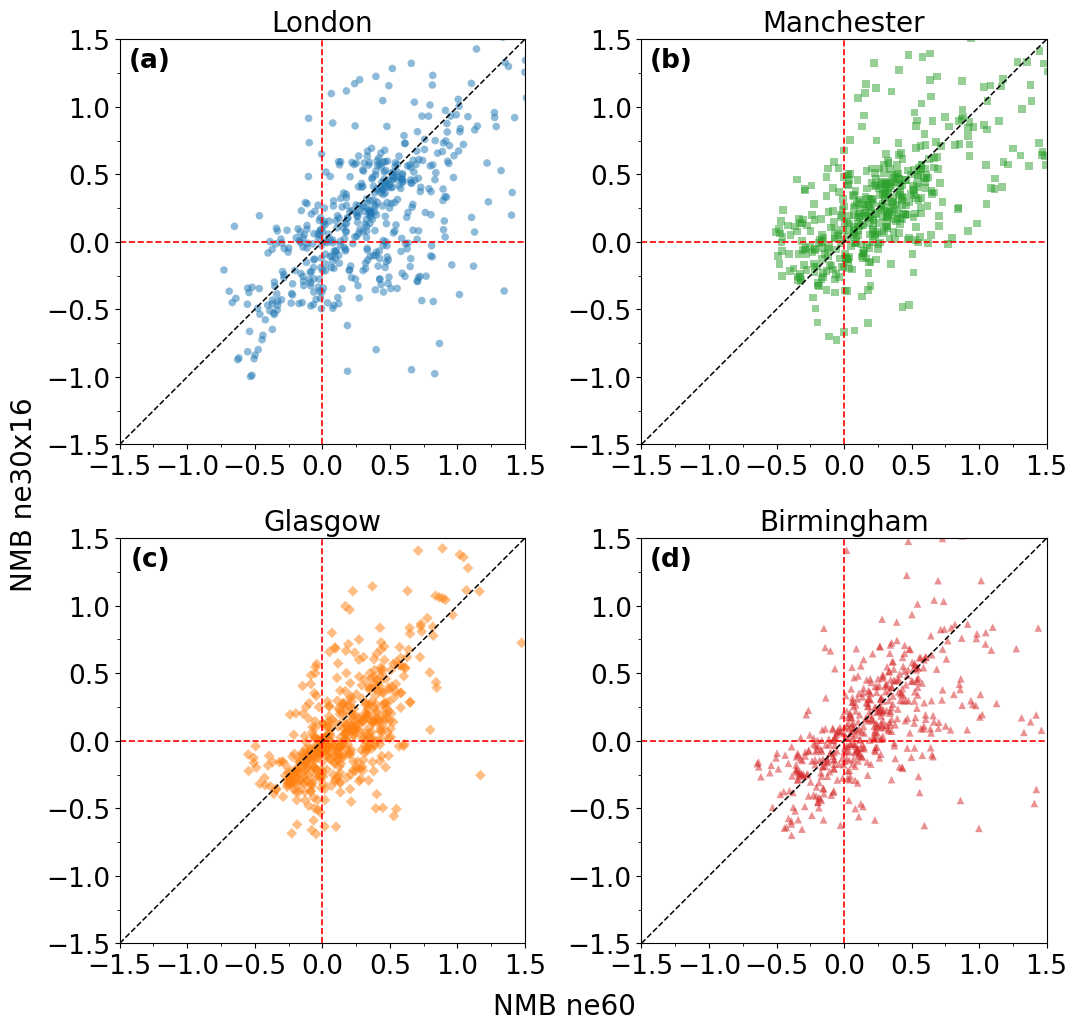

In [33]:
def plot_figure_s6(nmb_data):
    cities = list(city_lonlat.keys())
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()

    for i, city in enumerate(cities):
        ax = axes[i]
        x_nmb60, y_nmb30 = nmb_data[city]

        lim_raw = max(np.nanmax(np.abs(x_nmb60)), np.nanmax(np.abs(y_nmb30)))
        lim = max(0.8, min(1.5, np.ceil((lim_raw + 0.05) * 10) / 10))

        ax.axvline(0, color='red', linestyle='--', linewidth=1.2)
        ax.axhline(0, color='red', linestyle='--', linewidth=1.2)
        ax.plot([-lim, lim], [-lim, lim], linestyle='--', color='black', linewidth=1.1)

        ax.scatter(x_nmb60, y_nmb30, s=30, alpha=0.5, linewidth=0.4, edgecolor='none', **style[city])

        ax.set_title(city, fontsize=20)
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ax.set_aspect('equal', 'box')
        ax.grid(False)
        ax.xaxis.set_major_locator(MultipleLocator(0.5))
        ax.xaxis.set_minor_locator(AutoMinorLocator(2))
        ax.yaxis.set_major_locator(MultipleLocator(0.5))
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.tick_params(axis='both', labelsize=19)

    fig.text(0.5, -0.02, 'NMB ne60', ha='center', fontsize=20)
    fig.text(0.038, 0.5, 'NMB ne30x16', va='center', rotation='vertical', fontsize=20)

    labels = ['(a)', '(b)', '(c)', '(d)']
    for ax, label in zip(axes, labels):
        ax.text(
            0.125, 0.98,
            label,
            transform=ax.transAxes,
            fontsize=19,
            fontweight='bold',
            va='top', ha='right',
        )

    plt.tight_layout(w_pad=-8.0, h_pad=2.0)
    return fig, axes
fig, axes = plot_figure_s6(nmb_data)


In [ ]:
figure_data_dir = BASE_DIR / 'figure_data'
figure_data_dir.mkdir(parents=True, exist_ok=True)
figure_s6_path = figure_data_dir / 'FigureS6.nc'

max_points = max(len(values[0]) for values in nmb_data.values())
data_vars = {}
for city, (x_nmb60, y_nmb30) in nmb_data.items():
    key = city.lower()
    padded_x = np.full(max_points, np.nan)
    padded_y = np.full(max_points, np.nan)
    padded_x[:len(x_nmb60)] = x_nmb60
    padded_y[:len(y_nmb30)] = y_nmb30
    data_vars[f'{key}_nmb_ne60'] = (('time',), padded_x)
    data_vars[f'{key}_nmb_ne30x16'] = (('time',), padded_y)

FigureS6 = xr.Dataset(data_vars=data_vars)
FigureS6.to_netcdf(figure_s6_path)
FigureS6.close()
print(figure_s6_path)

/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figure_data/FigureS6.nc


In [ ]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

BASE_DIR = Path('/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision')
figure_s6_path = BASE_DIR / 'figure_data' / 'FigureS6.nc'
FigureS6_saved = xr.open_dataset(figure_s6_path)

city_lonlat = {
    'London': [360 - 0.213492, 51.521050],
    'Manchester': [360 - 2.237881, 53.481520],
    'Glasgow': [360 - 4.259122, 55.858940],
    'Birmingham': [360 - 1.874978, 52.476145],
}

style = {
    'London': dict(color='tab:blue', marker='o'),
    'Manchester': dict(color='tab:green', marker='s'),
    'Glasgow': dict(color='tab:orange', marker='D'),
    'Birmingham': dict(color='tab:red', marker='^'),
}

saved_nmb_data = {}
for city in city_lonlat:
    key = city.lower()
    x_nmb60 = FigureS6_saved[f'{key}_nmb_ne60'].values
    y_nmb30 = FigureS6_saved[f'{key}_nmb_ne30x16'].values
    mask = np.isfinite(x_nmb60) & np.isfinite(y_nmb30)
    saved_nmb_data[city] = (x_nmb60[mask], y_nmb30[mask])

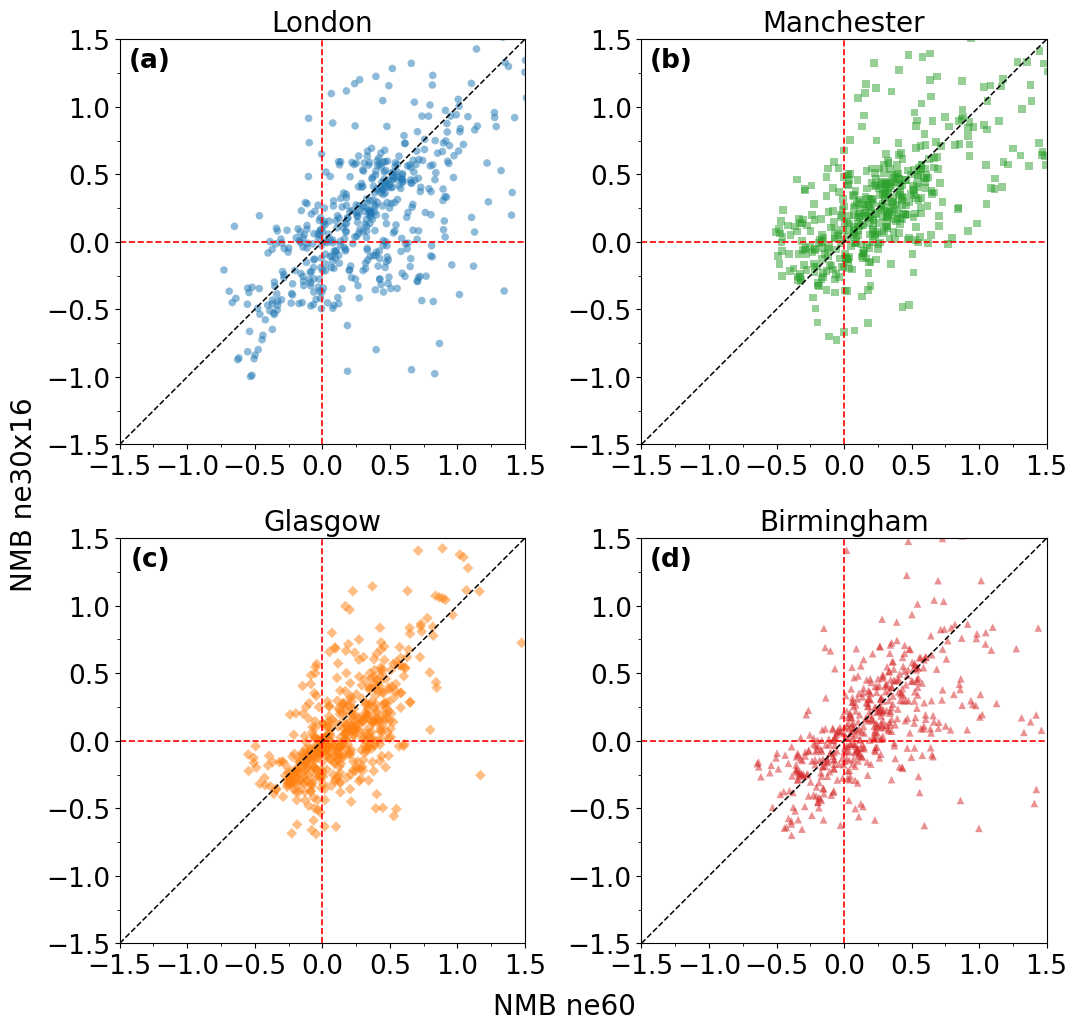

In [ ]:
def plot_figure_s6(nmb_data):
    cities = list(city_lonlat.keys())
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()

    for i, city in enumerate(cities):
        ax = axes[i]
        x_nmb60, y_nmb30 = nmb_data[city]

        lim_raw = max(np.nanmax(np.abs(x_nmb60)), np.nanmax(np.abs(y_nmb30)))
        lim = max(0.8, min(1.5, np.ceil((lim_raw + 0.05) * 10) / 10))

        ax.axvline(0, color='red', linestyle='--', linewidth=1.2)
        ax.axhline(0, color='red', linestyle='--', linewidth=1.2)
        ax.plot([-lim, lim], [-lim, lim], linestyle='--', color='black', linewidth=1.1)

        ax.scatter(x_nmb60, y_nmb30, s=30, alpha=0.5, linewidth=0.4, edgecolor='none', **style[city])

        ax.set_title(city, fontsize=20)
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ax.set_aspect('equal', 'box')
        ax.grid(False)
        ax.xaxis.set_major_locator(MultipleLocator(0.5))
        ax.xaxis.set_minor_locator(AutoMinorLocator(2))
        ax.yaxis.set_major_locator(MultipleLocator(0.5))
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.tick_params(axis='both', labelsize=19)

    fig.text(0.5, -0.02, 'NMB ne60', ha='center', fontsize=20)
    fig.text(0.038, 0.5, 'NMB ne30x16', va='center', rotation='vertical', fontsize=20)

    labels = ['(a)', '(b)', '(c)', '(d)']
    for ax, label in zip(axes, labels):
        ax.text(
            0.125, 0.98,
            label,
            transform=ax.transAxes,
            fontsize=19,
            fontweight='bold',
            va='top', ha='right',
        )

    plt.tight_layout(w_pad=-8.0, h_pad=2.0)
    return fig, axes
fig, axes = plot_figure_s6(saved_nmb_data)


# FIGURES_DIR = BASE_DIR / 'figures' / 'SI'
# FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# RASTER_DPI = 300
# png_path = FIGURES_DIR / 'FigureS6.png'
# pdf_path = FIGURES_DIR / 'FigureS6.pdf'

# fig.savefig(png_path, dpi=RASTER_DPI, bbox_inches='tight', facecolor='white')

# img = plt.imread(png_path)
# height_px, width_px = img.shape[:2]
# pdf_fig = plt.figure(figsize=(width_px / RASTER_DPI, height_px / RASTER_DPI), dpi=RASTER_DPI)
# pdf_ax = pdf_fig.add_axes([0, 0, 1, 1])
# pdf_ax.imshow(img)
# pdf_ax.axis('off')
# pdf_fig.savefig(pdf_path, format='pdf', dpi=RASTER_DPI, bbox_inches=None, pad_inches=0, facecolor='white')
# plt.close(pdf_fig)